In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

import jax
from jax import grad, jit, vmap, jacfwd, jacrev, value_and_grad, jvp
import jax.numpy as jnp
import jax.random as jr

jax.config.update("jax_enable_x64", True)
colors = sns.color_palette()
key = jr.PRNGKey(0)

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Example: Brownian Motion


Brownian motion was first observed as the irregular motion of small particles suspended in a fluid. Einstein connected the phenomenon to molecular motion {cite:p}`einstein1905brownian`, and Wiener later constructed its mathematical model {cite:p}`wiener1923differential`.

For our purposes, we will be using the terms Brownian motion and Wiener process interchangeably. 

The Wiener process is a continuous-time stochastic process that plays an important role in many parts of mathematics and physics. It is the continuous-time limit of a discrete random walk. We begin with the random walk:

$$
S_n = \sum_{i=1}^{n} X_i
$$

where $X_i$ are independent and identically distributed random variables with mean 0 and variance 1, and $S_0=0$. For each $n$, define the diffusively rescaled random walk by

$$
W_n(t) = \frac{1}{\sqrt{n}} S_{\lfloor nt\rfloor},\qquad 0\leq t\leq 1.
$$

As $n \to \infty$, the processes $W_n$ converge in distribution to a Wiener process. This limiting result is Donsker's theorem. The construction below illustrates the convergence with a finite random walk.



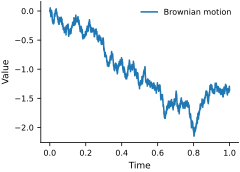

In [3]:
def random_walk(key, n):
    """
    Generate a random walk sequence S_n based on i.i.d. random variables.

    Args:
        key: PRNG key for reproducibility.
        n: Length of the random walk.

    Returns:
        Partial sums from S_0 through S_n.
    """
    # Generate n i.i.d. random variables with mean 0 and variance 1
    x = jr.normal(key, shape=(n,))
    # Compute partial sums
    S_n = jnp.concatenate((jnp.zeros(1), jnp.cumsum(x)))
    return S_n

def limit_random_walk(key, n, t_points):
    """
    Generate a Brownian motion (diffusively rescaled random walk).

    Args:
        key: PRNG key for reproducibility.
        n: Number of steps in the random walk.
        t_points: Array of time points in [0, 1] at which to evaluate the process.

    Returns:
        Array of Brownian motion values at specified t_points.
    """
    # Generate random walk sequence
    S_n = random_walk(key, n)
    # Map t_points to indices ⌊nt⌋
    indices = jnp.floor(n * t_points).astype(int)
    # Rescale by √n to get diffusively rescaled random walk
    W_n_t = S_n[indices] / jnp.sqrt(n)
    return W_n_t

# Number of steps in random walk
n_steps = 10000 
t_points = jnp.linspace(0, 1, n_steps + 1)

# Generate Brownian motion
bm_values = limit_random_walk(key, n_steps, t_points)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, bm_values, label="Brownian motion")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
finalize_axes(keep_box=False)
plt.show()

## Simulation

Now as n goes to infinity, this discrete random walk converges to the Wiener process. Try playing with the number of steps to see it converge.

To simulate the Wiener process on a grid $t_k=k\Delta t$, use the recursion

$$
W_0=0,\qquad
W_{t_k}=W_{t_{k-1}}+\sqrt{\Delta t}\,Z_k,\qquad k=1,\ldots,N,
$$

where the $Z_k$ are independent standard normal random variables and $\Delta t$ is the time step.

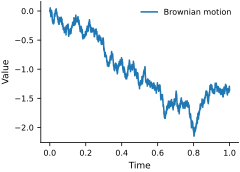

In [4]:
# define the Brownian motion without the random walk function
def brownian_motion_1d(key, n_steps):
    dt = 1.0 / n_steps
    dW = jnp.sqrt(dt) * jr.normal(key, (n_steps,))
    W = jnp.concatenate((jnp.zeros(1), jnp.cumsum(dW)))
    return W

# Number of steps in random walk
n_steps = 10000 
t_points = jnp.linspace(0, 1, n_steps + 1)

# Generate Brownian motion
bm_values = brownian_motion_1d(key, n_steps)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, bm_values, label="Brownian motion")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
finalize_axes(keep_box=False)
plt.show()

Notice that it is the same as the limit of the diffusively rescaled random walk (if you use the same key and number of steps).

Okay, you can see the randomness. Let's simulate it a few times to examine its behavior.

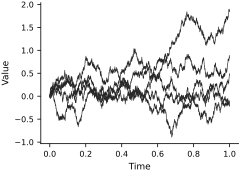

In [5]:
n_samples = 5

# Generate multiple Brownian motion samples
bm_samples = vmap(lambda key: brownian_motion_1d(key, n_steps))(jr.split(key, n_samples))

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
for i in range(n_samples):
    ax.plot(t_points, bm_samples[i], color='0.15', linewidth=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
finalize_axes(keep_box=False)
plt.show()

As illustrated in {numref}`fig-brownian-paths`, paths that start at the same value separate immediately. The first two moments of the Wiener process are

\begin{align*}
\mathbb{E}[W_t] &= 0, \\
\operatorname{Var}[W_t] &= t.
\end{align*}

We verify this scaling numerically.

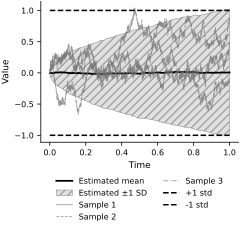

In [6]:
# Sample many Brownian motion paths and compute the mean and variance at each time point
n_samples = 1000
bm_samples = vmap(lambda key: 
                  brownian_motion_1d(key, n_steps))(jr.split(key, n_samples))
mean_values = jnp.mean(bm_samples, axis=0)
var_values = jnp.var(bm_samples, axis=0)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, mean_values, color='black', linewidth=1.8, label="Estimated mean")
ax.fill_between(t_points, mean_values - jnp.sqrt(var_values), mean_values + jnp.sqrt(var_values),
                facecolor='0.88', edgecolor='0.55', hatch='///', linewidth=0.5,
                label="Estimated ±1 SD")
# Plot a few samples
path_styles = ['-', '--', '-.']
for i in range(3):
    ax.plot(t_points, bm_samples[i], color='0.45', linestyle=path_styles[i],
            alpha=0.75, linewidth=0.8, label=f"Sample {i+1}")
ax.hlines(1, 0, 1, color="black", linestyle="--", label="+1 std")
ax.hlines(-1, 0, 1, color="black", linestyle="--", label="-1 std")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
finalize_axes(keep_box=False)
plt.show()

Let's plot the statistics as a function of time.

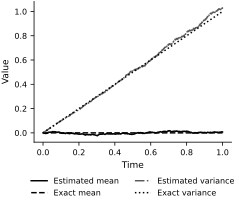

In [7]:
# Plot the mean and variance a function of time
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, mean_values, color='black', linestyle='-', label="Estimated mean")
ax.hlines(0, 0, 1, color='black', linestyle='--', label="Exact mean")
ax.plot(t_points, var_values, color='0.35', linestyle='-.', label="Estimated variance")
ax.plot(t_points, t_points, color='black', linestyle=':', label="Exact variance")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
finalize_axes(keep_box=False)
plt.show()

As {numref}`fig-brownian-moments` confirms, the estimated mean remains near zero and the variance grows linearly with time.

### Brownian Motion in 2D

Let's take a look at a Brownian motion in 2D. We can simulate it by simulating two independent Wiener processes and plotting them against each other.

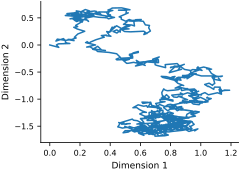

In [8]:
def brownian_motion_2d(key, n):
    """Generates a 2d Brownian motion with n steps."""
    key, subkey = jr.split(key)
    # Generate two independent 1D Brownian motions
    W_n_t = jnp.stack([brownian_motion_1d(key, n), 
                       brownian_motion_1d(subkey, n)], axis=1)
    return W_n_t

n_steps = 1000

# Generate 2D Brownian motion
bm_2d_values = brownian_motion_2d(key, n_steps)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(bm_2d_values[:, 0], bm_2d_values[:, 1])
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
finalize_axes(keep_box=False)
plt.show()

This resembles the Brownian motion observed for particles. The construction extends to three and higher dimensions.

### Brownian Bridge

Let's now look at the Brownian bridge. It is a Wiener process that starts at 0 and ends at 0. We can define it as:

$$
B(t) = W(t) - \frac{t}{T} W(T)
$$

where $T$ is the final time. We now simulate this process.

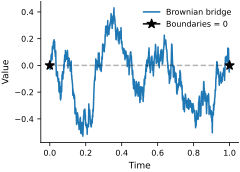

In [9]:
def brownian_bridge_1d(key, n, t_points):
    """
    Generate a Brownian bridge (conditioned Brownian motion to return to 0 at T).

    Args:
        key: PRNG key for reproducibility.
        n: Number of steps in the Brownian motion.
        t_points: Array of time points in [0, 1] at which to evaluate the process.

    Returns:
        Array of Brownian bridge values at specified t_points.
    """
    # Generate Brownian motion using the earlier function
    W_t = brownian_motion_1d(key, n)

    # Brownian Bridge transformation: B(t) = W(t) - t * W(T)
    # Define the end time
    T = -1 
    W_T = W_t[T]  # Value of Brownian motion at T
    B_t = W_t - t_points * W_T  # Apply the transformation

    return B_t

n_steps = 1000
t_points = jnp.linspace(0, 1, n_steps + 1)

# Generate Brownian bridge
bb_values = brownian_bridge_1d(key, n_steps, t_points)

t_points = jnp.linspace(0, 1, n_steps + 1)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, bb_values, label="Brownian bridge")
ax.plot(0, 0, marker="*", markersize=10, color="black", label="Boundaries = 0")
ax.plot(1, 0, marker="*", markersize=10, color="black")
ax.hlines(0, 0, 1, color="black", alpha=0.3, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
finalize_axes(keep_box=False)
plt.show()

If we sample it many times, we will see that the variance decreases as we get closer to the end point.

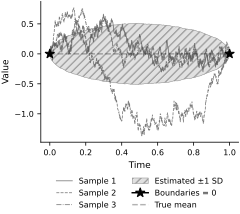

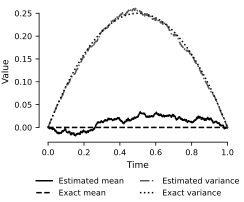

In [10]:
n_samples = 1000

# Generate multiple Brownian bridge samples
bb_samples = vmap(lambda key: 
                  brownian_bridge_1d(key, n_steps, t_points))(jr.split(key, n_samples))
bb_mean = jnp.mean(bb_samples, axis=0)
bb_var = jnp.var(bb_samples, axis=0)
true_mean = jnp.zeros_like(t_points)
true_var = t_points * (1 - t_points)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
path_styles = ['-', '--', '-.']
for i in range(3):
    ax.plot(t_points, bb_samples[i], color='0.35', linestyle=path_styles[i],
            alpha=0.8, linewidth=0.8, label=f"Sample {i+1}")
ax.fill_between(t_points, -jnp.sqrt(bb_var), jnp.sqrt(bb_var),
                facecolor='0.88', edgecolor='0.55', hatch='///', linewidth=0.5,
                label="Estimated ±1 SD")
# Plot big stars at the boundaries
ax.plot(0, 0, marker="*", markersize=10, color="black", label="Boundaries = 0")
ax.plot(1, 0, marker="*", markersize=10, color="black")
ax.hlines(0, 0, 1, color="black", alpha=0.3, linestyle="--", label="True mean")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
finalize_axes(keep_box=False)
plt.show()

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, bb_mean, color='black', linestyle='-', label="Estimated mean")
ax.plot(t_points, true_mean, color='black', linestyle='--', label="Exact mean")
ax.plot(t_points, bb_var, color='0.35', linestyle='-.', label="Estimated variance")
ax.plot(t_points, true_var, color='black', linestyle=':', label="Exact variance")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
sns.despine(trim=True)
plt.show()

#### Exercises

1. How many samples do you need to obtain reliable agreement with the true mean and variance?

This Brownian bridge can be represented as its Karhunen-Loeve expansion. The Karhunen-Loeve expansion is a representation of a stochastic process as an infinite sum of orthogonal functions. Fun fact: these are the eigenvalues and eigenfunctions of the Poisson equation with Dirichlet boundary conditions. The Karhunen-Loeve expansion of the Brownian bridge is given by:

$$
B(t) = \sum_{n=1}^{\infty} Z_n \frac{\sqrt{2} \sin(n \pi t)}{n \pi}
$$

where $Z_n$ are independent standard normal random variables. We now simulate the Brownian bridge.

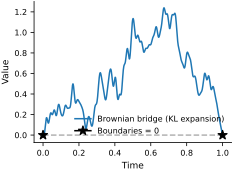

In [11]:
def brownian_bridge_kl(key, t_points, num_terms=100):
    """
    Generate a Brownian Bridge using the Karhunen–Loève (KL) expansion.

    Args:
        key: PRNG key for reproducibility.
        t_points: Array of time points in [0, 1] at which to evaluate the process.
        num_terms: Number of terms in the KL expansion.

    Returns:
        Array of Brownian Bridge values at specified t_points.
    """
    t_points = jnp.asarray(t_points)
    n = jnp.arange(1, num_terms + 1)  # KL expansion term indices from 1 through num_terms
    
    # Generate independent Gaussian random variables ξ_n ~ N(0, 1)
    keys = jr.split(key, num_terms)
    xi_n = jnp.array([jr.normal(k) for k in keys])
    
    # Compute the Brownian Bridge using the KL expansion
    terms = [
        xi_n[i] * jnp.sqrt(2)  * jnp.sin(n[i] * jnp.pi * t_points) / (jnp.pi * n[i])
        for i in range(num_terms)
    ]
    B_t = jnp.sum(jnp.stack(terms, axis=0), axis=0)
    
    return B_t

n_terms = 100

# Generate Brownian bridge using KL expansion
bb_kl_values = brownian_bridge_kl(key, t_points, num_terms=n_terms)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, bb_kl_values, label="Brownian bridge (KL expansion)")
# Plot big stars at the boundaries
ax.plot(0, 0, marker="*", markersize=10, color="black", label="Boundaries = 0")
ax.plot(1, 0, marker="*", markersize=10, color="black")
ax.hlines(0, 0, 1, color="black", alpha=0.3, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
finalize_axes(keep_box=False)
ax.legend()
plt.show()

Okay, that doesn't look quite like we want, try playing around with the number of terms to see how many it takes to look like a Brownian bridge.

Let's see if we can recover the variance of the Brownian bridge with the expansion.

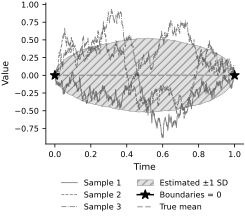

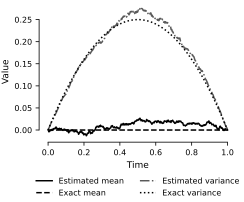

In [12]:
n_samples = 1000

n_terms = 1000

# Generate multiple Brownian bridge samples using KL expansion
bb_kl_samples = vmap(lambda key: 
                     brownian_bridge_kl(key, t_points, num_terms=n_terms))(jr.split(key, n_samples))
bb_kl_mean = jnp.mean(bb_kl_samples, axis=0)
bb_kl_var = jnp.var(bb_kl_samples, axis=0)
kl_true_mean = jnp.zeros_like(t_points)
kl_true_var = t_points * (1 - t_points)

# Visualize
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
path_styles = ['-', '--', '-.']
for i in range(3):
    ax.plot(t_points, bb_kl_samples[i], color='0.35', linestyle=path_styles[i],
            alpha=0.8, linewidth=0.8, label=f"Sample {i+1}")
ax.fill_between(t_points, -jnp.sqrt(bb_kl_var), jnp.sqrt(bb_kl_var),
                facecolor='0.88', edgecolor='0.55', hatch='///', linewidth=0.5,
                label="Estimated ±1 SD")
# Plot big stars at the boundaries
ax.plot(0, 0, marker="*", markersize=10, color="black", label="Boundaries = 0")
ax.plot(1, 0, marker="*", markersize=10, color="black")
ax.hlines(0, 0, 1, color="black", alpha=0.3, linestyle="--", label="True mean")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
finalize_axes(keep_box=False)
plt.show()

# Plot the mean and variance a function of time
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(t_points, bb_kl_mean, color='black', linestyle='-', label="Estimated mean")
ax.plot(t_points, kl_true_mean, color='black', linestyle='--', label="Exact mean")
ax.plot(t_points, bb_kl_var, color='0.35', linestyle='-.', label="Estimated variance")
ax.plot(t_points, kl_true_var, color='black', linestyle=':', label="Exact variance")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
sns.despine(trim=True)
plt.show()

#### Exercises

1. How many terms and samples do you need for the KL expansion to agree with the true mean and variance?

### Tied-down Brownian Sheet (KL Expansion)

The two-dimensional analogue constructed here is more precisely a *tied-down Brownian sheet*, also called a Brownian pillow. A standard Brownian sheet is zero along the two axes $t_1=0$ and $t_2=0$, whereas the tied-down version below is zero along all four edges of $[0,1]^2$. Its Karhunen--Loève expansion is

$$
B(t_1, t_2) = \sum_{n=1}^{\infty} \sum_{m=1}^{\infty} Z_{nm} \frac{2 \sin(n \pi t_1) \sin(m \pi t_2)}{n m \pi^2}
$$

where the $Z_{nm}$ are independent standard normal random variables.

In [13]:
def tied_down_brownian_sheet_kl(key, t1, t2, num_terms=20):
    """
    Generate a tied-down Brownian sheet using its KL expansion.

    Args:
        key: PRNG key for reproducibility.
        t1: 1D array of s-values in [0, 1].
        t2: 1D array of t-values in [0, 1].
        num_terms: Number of terms M=N in the KL expansion.

    Returns:
        A 2D array representing the tied-down Brownian sheet.
    """
    t1 = jnp.asarray(t1)
    t2 = jnp.asarray(t2)
    m = jnp.arange(1, num_terms + 1)
    n = jnp.arange(1, num_terms + 1)

    # Generate independent Gaussian random variables Z_{m,n} ~ N(0,1)
    keys = jr.split(key, num_terms**2)
    xi_mn = jnp.array([jr.normal(k) for k in keys]).reshape(num_terms, num_terms)

    # Compute coefficients: 2/(pi^2 * m * n)
    coef = 2.0 / (jnp.pi**2 * (m[:, None] * n[None, :]))

    # Compute sine terms for s and t
    sin_t1 = jnp.sin(jnp.pi * t1[:, None] * m[None, :])    # (S, M)
    sin_t2 = jnp.sin(jnp.pi * t2[:, None] * n[None, :])    # (T, N)

    # Combine random coefficients and scaling
    XiC = xi_mn * coef  # (M,N)

    # Construct W(s,t) by summing over m,n:
    # W = sin_s * XiC * sin_t^T in a matrix-multiplication sense
    W_st = sin_t1 @ XiC @ sin_t2.T

    return W_st

t1_points = jnp.linspace(0, 1, 100)
t2_points = jnp.linspace(0, 1, 100)

# Generate a tied-down Brownian sheet using its KL expansion
W_values = tied_down_brownian_sheet_kl(key, t1_points, t2_points, num_terms=100)

# Create a contour plot of the tied-down Brownian sheet
T1, T2 = jnp.meshgrid(t1_points, t2_points, indexing='ij')

In [14]:
# 3D plot
fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T1, T2, W_values, cmap='Greys', rstride=1, cstride=1,
                       edgecolor='0.45', linewidth=0.15, antialiased=True)
# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_xlabel("t1")
ax.set_ylabel("t2")
ax.set_zlabel("W(s,t)")
finalize_axes(keep_box=False)
plt.show()

Note how the edges of the sheet are all pinned to zero, similar to the Brownian bridge. Also just from the expansion we can see that the sine functions will make the sheet zero at the edges.

For a broader treatment of random fields and their probability theory, see Part I of {cite:t}`adler2007random`.

### Exercise
Can you think of other phenomena that can be modeled as a Wiener process? 

The stochastic-exponential-growth example uses the Wiener process to model a stochastic system.